In [ ]:
import pandas as pd
import numpy as np
import nltk
import string
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [62]:
df = pd.read_csv("email_spam.csv", encoding='latin-1')

print(df.shape)
print(df.head())

(5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [63]:
df = df[['v1','v2']].copy()
df.columns = ['label','message']
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [64]:
df['label'] = df['label'].map({'ham':0,'spam':1})

In [65]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    text = str(text).lower()
    text = "".join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]
    words = [ps.stem(word) for word in words]
    return " ".join(words)

In [66]:
df['clean_message'] = df['message'].apply(preprocess_text)
print(df['clean_message'].head())

0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri 2 wkli comp win fa cup final tkt 21...
3                  u dun say earli hor u c alreadi say
4            nah dont think goe usf live around though
Name: clean_message, dtype: object


In [67]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_message'])
y = df['label']
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
model = MultinomialNB()
model.fit(X_train, y_train)
# prediction
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Naive bayes Accuracy:", accuracy)

Naive bayes Accuracy: 0.9614349775784753


In [69]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression model
lr_model = LogisticRegression()

# train model
lr_model.fit(X_train, y_train)

# prediction
lr_pred = lr_model.predict(X_test)

# accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.9443946188340807


In [70]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
# Naive Bayes metrics
nb_accuracy = accuracy_score(y_test, y_pred)
nb_precision = precision_score(y_test, y_pred)
nb_recall = recall_score(y_test, y_pred)
nb_f1 = f1_score(y_test, y_pred)

print("Naive Bayes Metrics")
print("Accuracy:", round(nb_accuracy,3))
print("Precision:", round(nb_precision,3))
print("Recall:", round(nb_recall,3))
print("F1 Score:", round(nb_f1,3))


# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("\nLogistic Regression Metrics")
print("Accuracy:", round(lr_accuracy,3))
print("Precision:", round(lr_precision,3))
print("Recall:", round(lr_recall,3))
print("F1 Score:", round(lr_f1,3))

Naive Bayes Metrics
Accuracy: 0.961
Precision: 1.0
Recall: 0.713
F1 Score: 0.833

Logistic Regression Metrics
Accuracy: 0.944
Precision: 0.958
Recall: 0.613
F1 Score: 0.748


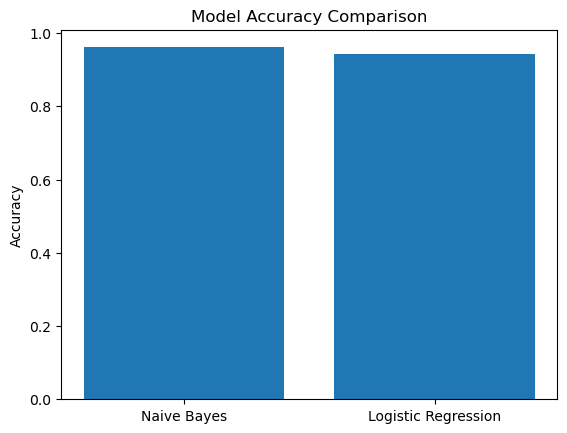

In [71]:
models = ['Naive Bayes','Logistic Regression']
accuracy = [0.961,0.944]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [72]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[965   0]
 [ 43 107]]


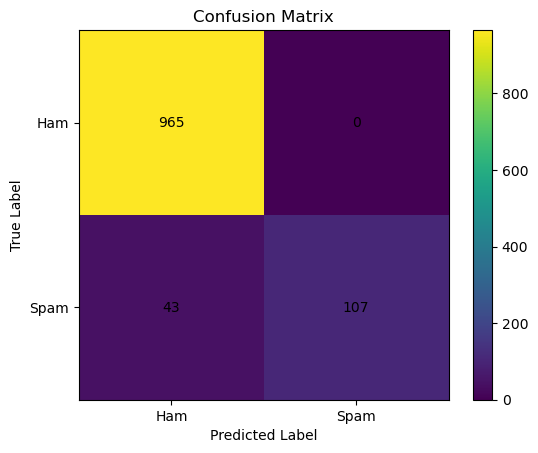

In [73]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

labels = ['Ham','Spam']
tick_marks = np.arange(len(labels))

plt.xticks(tick_marks, labels)
plt.yticks(tick_marks, labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [74]:
email = ["Congratulations! You won a free lottery"]
email_clean = [preprocess_text(email[0])]
email_vector = tfidf.transform(email_clean)
prediction = model.predict(email_vector)
if prediction[0] == 1:
    print("Spam Email")
else:
    print("Ham Email")

Spam Email


In [94]:
import pickle

pickle.dump(model, open("model.pkl","wb"))
pickle.dump(tfidf, open("vectorizer.pkl","wb"))